In [9]:
import os
from langgraph.graph import START,END,MessagesState,state,StateGraph
from langgraph.store.memory import InMemoryStore
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
from langchain_huggingface import HuggingFaceEndpointEmbeddings
from dotenv import load_dotenv
from langchain_core.runnables import RunnableConfig
from langgraph.store.memory import BaseStore
load_dotenv()



True

In [3]:
model=ChatGroq(model="openai/gpt-oss-120b",temperature=0.2,api_key=os.getenv("GROQ_API_KEY"))

In [4]:
store=InMemoryStore()

user_id="u1"
user_details=("users",user_id,"details")


store.put(user_details,"prefernces1",{"data":"i love to teaching on youtube"})
store.put(user_details, "profile_1", {"data": "Name: Rahul, Age: 30"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [5]:
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Rahul...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""


In [8]:
def chat_node(state:MessagesState,config:RunnableConfig,store:BaseStore):

    user_id=config['configurable']['user_id']

    #read only the details
    user_details=("user",user_id,"details")
    item=store.search(user_details)

    if item:
        user_details_content="/n".join(f"- {it.value.get("data"," ")}" for it in item)
    else:
        user_details_content=" "

    system_prompts=SYSTEM_PROMPT_TEMPLATE.format(user_details_content=user_details_content)

    system_msg=SystemMessage(content=system_prompts)

    response=model.invoke([system_msg]+state['messages'])

    return {"messages":[response]}

In [10]:
builder=StateGraph(MessagesState)
builder.add_node("chat_node",chat_node)
builder.add_edge(START,"chat_node")
builder.add_edge("chat_node",END)
graph=builder.compile(store=store)

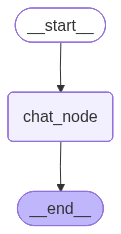

In [11]:
graph

In [13]:
config={"configurable":{"user_id":"u1"}}

result=graph.invoke({"messages":[HumanMessage(content="explain me the gen ai ?")]},config=config)
print(result['messages'][-1].content)

Sure! Let’s break down **generative AI** (often shortened to “Gen AI”) in a friendly, easy‑to‑understand way.

---

## 1. What is generative AI?

Generative AI refers to a class of machine‑learning models that can **create new content**—text, images, music, code, video, and more—rather than just recognizing or classifying what already exists. In other words, it *generates* data that looks (or sounds) as if a human produced it.

| Traditional AI (Discriminative) | Generative AI |
|--------------------------------|---------------|
| **Goal:** Predict a label (e.g., “spam?”) | **Goal:** Produce a realistic output (e.g., a paragraph, a picture) |
| Learns **what** something *is* | Learns **how** something *looks/behaves* |
| Example: Image classifier that says “cat” | Example: Model that draws a cat from scratch |

---

## 2. Core Techniques Behind Gen AI

| Technique | How It Works (Simplified) | Typical Outputs |
|-----------|---------------------------|-----------------|
| **Transformer

In [14]:
config={"configurable":{"user_id":"u1"}}

result=graph.invoke({"messages":[HumanMessage(content="what is langgraph ?")]},config=config)
print(result['messages'][-1].content)

**LangGraph** is an open‑source Python library that makes it easy to build **composable, state‑driven workflows** (often called “graphs”) for large‑language‑model (LLM) applications. Think of it as a lightweight framework for wiring together LLM calls, tool invocations, and custom logic into a directed graph where each node can read from and write to a shared state.

### Core ideas

| Concept | What it means | Why it matters |
|---------|---------------|----------------|
| **Graph of nodes** | Each node is a callable (e.g., an LLM chain, a function, a tool) that receives the current **state** and returns an updated state. | You can visualize and reason about the flow of data, just like a flowchart or a DAG. |
| **State** | A mutable dictionary (or any serializable object) that travels through the graph. Nodes can read, modify, or add keys. | Enables **memory** across steps without having to pass a bunch of arguments manually. |
| **Conditional edges** | Edges can be guarded by predicat

In [15]:
config={"configurable":{"user_id":"u1"}}

result=graph.invoke({"messages":[HumanMessage(content="hi my name is Rabul i love python  ?")]},config=config)
print(result['messages'][-1].content)

Hi Rabul! 👋 Great to meet a fellow Python enthusiast.

Since you love Python, here are a few ideas you might find useful:

1. **Project ideas** – If you’re looking for something fun to build, consider a web scraper with **BeautifulSoup**, a simple Flask API, or a data‑analysis notebook using **pandas** and **matplotlib**.  
2. **Learning resources** – The official Python docs are excellent, but you might also enjoy the “Python Crash Course” book or the free “Automate the Boring Stuff” online tutorial.  
3. **Tooling tips** – Using a virtual environment (`venv` or `conda`) keeps your dependencies tidy, and tools like **Black** (code formatter) and **ruff** (linter) can make your codebase look polished with minimal effort.

If you have a specific project in mind or want advice on a particular library, just let me know!

---

**What would you like to explore next?**  
1. Do you have a current Python project you’d like help brainstorming or debugging?  
2. Are you interested in learning ab